<div align="center">  
    
# Optimización de Retención de Clientes en Interconnect: Un Enfoque predictivo

</div>

**Resumen:** Este proyecto analiza datos de 7,043 clientes para predecir fugas. Se desarrolló un modelo LightGBM con un AUC-ROC de 0.89, identificando que los contratos mensuales y la antigüedad < 1 año son los mayores factores de riesgo.

# 1. Contexto y plan de trabajo
## 1.1. Diagnóstico del Sector y Justificación
   
En el sector de las telecomunicaciones, el Costo de Adquisición de Clientes (CAC) es significativamente más alto (entre 5 y 25 veces) que el costo de retener a un cliente existente. Las altas tasas de cancelación (Churn) impactan directamente en el margen de beneficio y reducen el Customer Lifetime Value (LTV).

Este proyecto se justifica en la necesidad de Interconnect de transicionar de una estrategia reactiva (intentar recuperar al cliente cuando ya canceló) a una proactiva (detectar patrones de riesgo antes de la fuga), permitiendo optimizar el presupuesto de marketing enfocándose solo en los usuarios con alta probabilidad de abandono.

## 1.2. Plan Aproximado de Resolución (Roadmap)

A continuación, presento el plan operativo expandido tras el análisis preliminar de los datos.

### 1.2.1. Descripción de los Datos y Estado Inicial

Tras la carga inicial y fusión de las 4 tablas (contract, personal, internet, phone), disponemos de un dataset con las siguientes características:

- **Volumen:** 7,043 registros (clientes) y 20 columnas potenciales.

- **Duplicados:** 0 duplicados explícitos encontrados.

- **Valores Nulos:** Se detectaron nulos estructurales en las columnas de servicios (OnlineSecurity, TechSupport, etc.) y MultipleLines, lo cual confirma que estos clientes no tienen contratados dichos servicios. Se imputarán como "No".

- **Tipos de Datos:** La columna TotalCharges se detectó como tipo objeto debido a espacios vacíos en clientes nuevos; requiere conversión a float.


| Variable | Conteo | Media | Desv. Std | Min | 25% | 50% (Mediana) | 75% | Max |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **MonthlyCharges** | 7,043 | 64.76 | 30.09 | 18.25 | 35.50 | 70.35 | 89.85 | 118.75 |
| **TotalCharges** | 7,043 | 2,279.73 | 2,266.79 | 0.00 | 398.55 | 1,394.55 | 3,786.60 | 8,684.80 |
| **SeniorCitizen** | 7,043 | 0.16 | 0.37 | 0 | 0 | 0 | 0 | 1 |



### 1.2.2. Definición del Problema y Stakeholders
   
- **Objetivo de Negocio:** Reducir la pérdida de ingresos mediante la detección temprana de clientes con alta probabilidad de fuga.

- **Stakeholders Identificados:**

    - **Marketing:** Requieren el listado de clientes en riesgo para enviar ofertas de retención personalizadas.

    - **Producto:** Necesitan saber qué servicios (ej. Fibra óptica vs. DSL) causan más insatisfacción.

    - **Finanzas:** Interesados en proyectar el Customer Lifetime Value (LTV) en riesgo.

### 1.2.3. Estrategia de limpieza, Variable Objetivo y Atributos Prioritarios

- **Estrategia de Imputación (Justificación):**

  - **TotalCharges:** Se imputarán los valores vacíos con 0. Justificación: Se verificó que estos casos corresponden a clientes con Tenure=0 (menos de 1 mes en la empresa), por lo que su facturación acumulada real es 0. Usar la media introduciría sesgo.

  - **Servicios (Internet/Teléfono):** Los NaN generados por el merge se rellenarán con 'No', indicando que el servicio no fue contratado.
   
- **Target (Variable Objetivo):** Se creará una variable binaria Churn:

    - 1 (Positivo): Si EndDate != 'No' (El cliente se fue).

    - 0 (Negativo): Si EndDate == 'No' (El cliente sigue activo).

- **Atributos Clave (Hipótesis):**

    - **Tenure (Antigüedad):** Calculada como FechaCorte (2020-02-01) - BeginDate. Se espera que clientes nuevos sean más volátiles.

    - **Type (Contrato):** Mensual vs. Anual.

    - **MonthlyCharges:** Sensibilidad al precio.


### 1.2.4. Métricas y KPIs (Evaluación)
   
Para alinear el modelo técnico con el negocio, se utilizarán las siguientes métricas y umbrales:


| Métrica | Fórmula / Concepto | Umbral Objetivo | Justificación |
| :--- | :--- | :--- | :--- |
| **AUC-ROC** | Área bajo la curva ROC. | **≥ 0.88** | Requisito crítico para la puntuación máxima. |
| **Accuracy** | $(TP + TN) / Total$ | N/A | Métrica de control secundaria. |
| **Recall** | $TP / (TP + FN)$ | Maximizar | Crítico para minimizar Falsos Negativos (clientes que se van sin ser detectados). |
| **Precision** | $TP / (TP + FP)$ | Monitorizar | Control del costo de las campañas (evitar descuentos innecesarios). |
| **F1-Score** | $2 \cdot \frac{P \cdot R}{P + R}$ | Balanceado | Métrica de compromiso ante desbalance de clases. |


### 1.2.5. Diseño Experimental

No se entrenará un solo modelo "a ciegas". Se seguirá este protocolo riguroso:

- **Reproducibilidad:** Se fijará random_state = 12345 en todas las divisiones y modelos para asegurar resultados consistentes.

- **Split de Datos:** Entrenamiento (75%) / Prueba (25%). Se usará stratify=y para mantener la proporción de Churn.

- **Manejo de Desbalance:** Se probará el hiperparámetro class_weight='balanced' en modelos de árboles y Regresión Logística.

- **Validación Cruzada (Cross-Validation):** Se utilizará GridSearchCV con 5 folds (cv=5) para asegurar que el resultado es robusto y no fruto del azar.

- **Selección de Modelos:**

    - Baseline: Regresión Logística.

    - Avanzados: Random Forest, LightGBM (Gradient Boosting).

### 1.2.6. Cronograma de Actividades (2 Semanas)

| Fase | Actividad | Tiempo Estimado | Entregable |
| :--- | :--- | :--- | :--- |
| **1. Prep** | 1. Imputación de nulos en servicios (rellenar con 'No').<br>2. Conversión de `TotalCharges` a numérico.<br>3. Creación de target `Churn` y feature `Tenure`. | Días 1-2 | Dataset Maestro Limpio (`df_merged`) |
| **2. EDA** | 1. Análisis de correlación (`heatmap`).<br>2. Gráficos de distribución de Churn por tipo de contrato.<br>3. Detección de outliers en cargos mensuales. | Días 3-4 | Reporte visual de patrones y hallazgos. |
| **3. Modelado** | 1. Codificación de variables (OHE/LabelEncoder).<br>2. Configuración de `GridSearchCV`.<br>3. Entrenamiento de 3 modelos (LogReg, RF, LGBM). | Días 5-9 | Tabla comparativa de modelos y métricas. |
| **4. Final** | 1. Evaluación final con Test Set.<br>2. Análisis de importancia de características.<br>3. Redacción de conclusiones. | Días 10-14 | Notebook Final y Reporte de Negocio. |

# 2. Inicialización

In [2]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler 
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report ,confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier 
from lightgbm import LGBMClassifier


sns.set_style('whitegrid')

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime

# ---------------------------------------------------------
# 1. CARGA DE DATOS
# ---------------------------------------------------------
try: 
    contract = pd.read_csv (r'C:\Users\juand\OneDrive\Escritorio\TripleTen\Telecom\Data\contract.csv')
    personal = pd.read_csv (r'C:\Users\juand\OneDrive\Escritorio\TripleTen\Telecom\Data\personal.csv')
    internet = pd.read_csv (r'C:\Users\juand\OneDrive\Escritorio\TripleTen\Telecom\Data\internet.csv')
    phone = pd.read_csv (r'C:\Users\juand\OneDrive\Escritorio\TripleTen\Telecom\Data\phone.csv')
except FileNotFoundError:
    print ("❌ Error: Asegúrate de subir los archivos al entorno.")

# ---------------------------------------------------------
# 2. FUSIÓN (MERGE)
# ---------------------------------------------------------
df_merged = contract.merge (personal, on='customerID', how='left')
df_merged = df_merged.merge (internet, on='customerID', how='left')
df_merged = df_merged.merge (phone, on='customerID', how='left')

# ---------------------------------------------------------
# 3. LIMPIEZA DE NULOS Y TIPOS DE DATOS
# ---------------------------------------------------------

# A) Rellenar Nulos de servicios
# Los NaNs generados por el merge significan que el cliente no tiene el servicio
# Lista de columnas que vienen de las tablas 'internet' y 'phone'

cols_servicios = [
    'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 
    'StreamingMovies', 'MultipleLines'
]

# Rellenamos con 'No'
for col in cols_servicios: 
    df_merged[col] = df_merged[col].fillna('No')

# B) Corregir TotalCharges
df_merged['TotalCharges'] = pd.to_numeric(df_merged['TotalCharges'], errors='coerce')

# Imputamos los nulos (Clientes nuevos con tenure 0) con 0
df_merged['TotalCharges'] = df_merged['TotalCharges'].fillna(0)

# ---------------------------------------------------------
# 4. FEATURE ENGINEERING (Ingeniería de Características)
# ---------------------------------------------------------

# A) Crear variable objectivo 'Churn' (Target)
# 1 = Se fue (EndDate tiene fecha), 0 = Se quedó (EndDate es 'No')
df_merged['Churn'] = (df_merged['EndDate']!='No').astype(int)

# B) Crear variable 'Tenure' (Antigüedad en días)
# Fecha de referencia dada por el negocio: 1 de febrero de 2020
fecha_corte = pd.to_datetime ('2020-02-01')

# Convertir BeginDate a datetime
df_merged['BeginDate'] = pd.to_datetime (df_merged['BeginDate'])

# Lógica: Si EndDate es 'No', usamos la fecha de corte. Si tiene fecha usamos esa.
df_merged['EndDate_Calc'] = df_merged['EndDate'].replace('No', fecha_corte)
df_merged['EndDate_Calc'] = pd.to_datetime(df_merged['EndDate_Calc'])

# Calculamos los días de diferencia 
df_merged['Tenure_Days'] = (df_merged['EndDate_Calc'] - df_merged['BeginDate']).dt.days

# ---------------------------------------------------------
# 5. REVISIÓN FINAL
# ---------------------------------------------------------

print (f'Dimensiones finales: {df_merged.shape}')
print ('\n--- Vista previa de las nuevas columnas ---')
display(df_merged[['customerID', 'BeginDate', 'EndDate', 'Churn', 'Tenure_Days', 'TotalCharges']].head())

print("\n--- Info del Dataset Maestro ---")
df_merged.info()

Dimensiones finales: (7043, 23)

--- Vista previa de las nuevas columnas ---


,customerID,BeginDate,EndDate,Churn,Tenure_Days,TotalCharges
0,7590-VHVEG,2020-01-01,No,0,31,29.85
1,5575-GNVDE,2017-04-01,No,0,1036,1889.50
2,3668-QPYBK,2019-10-01,2019-12-01 00:00:00,1,61,108.15
3,7795-CFOCW,2016-05-01,No,0,1371,1840.75
4,9237-HQITU,2019-09-01,2019-11-01 00:00:00,1,61,151.65



--- Info del Dataset Maestro ---
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customerID        7043 non-null   str           
 1   BeginDate         7043 non-null   datetime64[us]
 2   EndDate           7043 non-null   str           
 3   Type              7043 non-null   str           
 4   PaperlessBilling  7043 non-null   str           
 5   PaymentMethod     7043 non-null   str           
 6   MonthlyCharges    7043 non-null   float64       
 7   TotalCharges      7043 non-null   float64       
 8   gender            7043 non-null   str           
 9   SeniorCitizen     7043 non-null   int64         
 10  Partner           7043 non-null   str           
 11  Dependents        7043 non-null   str           
 12  InternetService   7043 non-null   str           
 13  OnlineSecurity    7043 non-null   str           
 14  O

C:\Users\juand\AppData\Local\Temp\ipykernel_6504\2679773217.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_merged, x='Churn', palette='coolwarm')


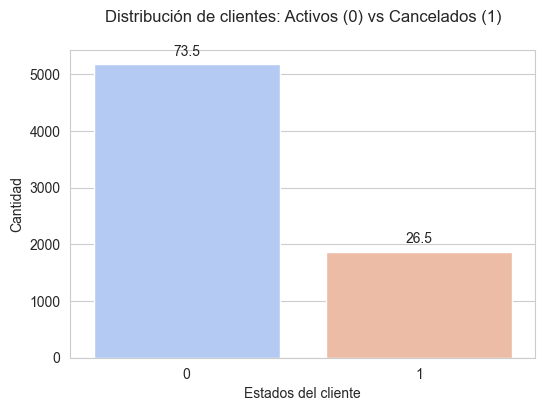

C:\Users\juand\AppData\Local\Temp\ipykernel_6504\2679773217.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot (data = df_merged, x='Churn', y='Tenure_Days', palette='Set2')


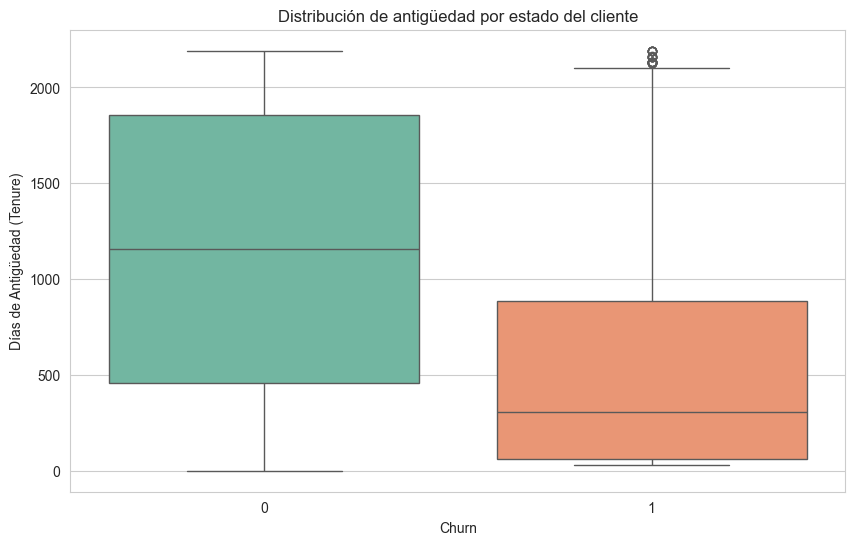

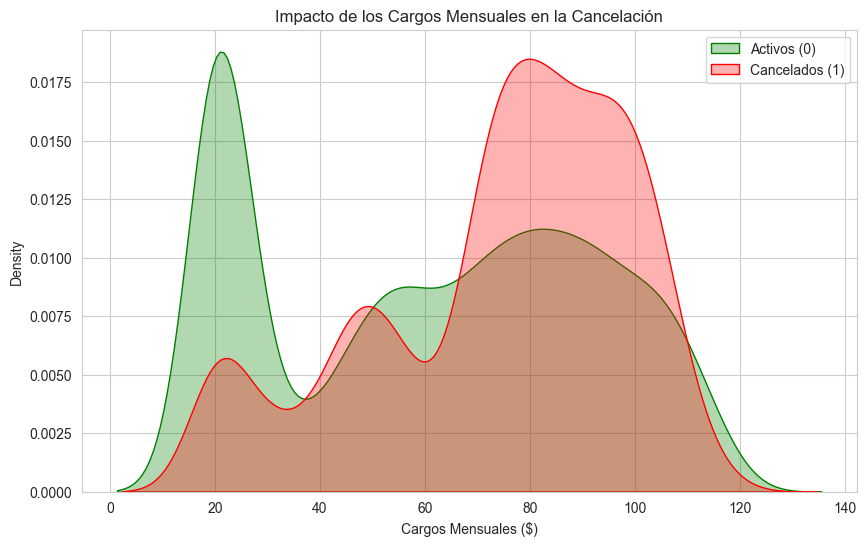

C:\Users\juand\AppData\Local\Temp\ipykernel_6504\2679773217.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot (data=contract_churn, x='Type', y='Churn', palette='viridis')


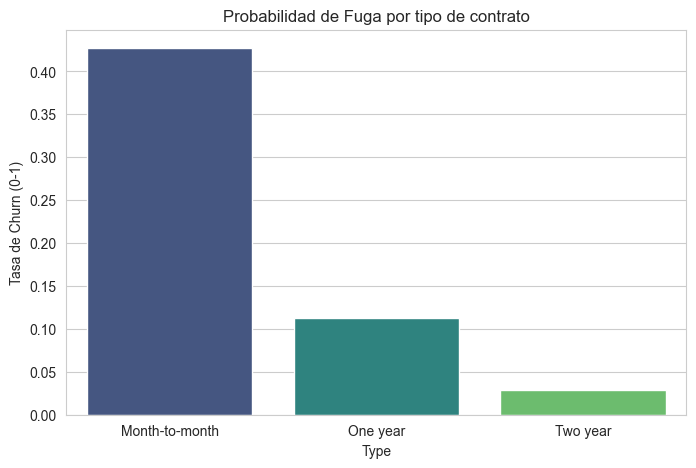

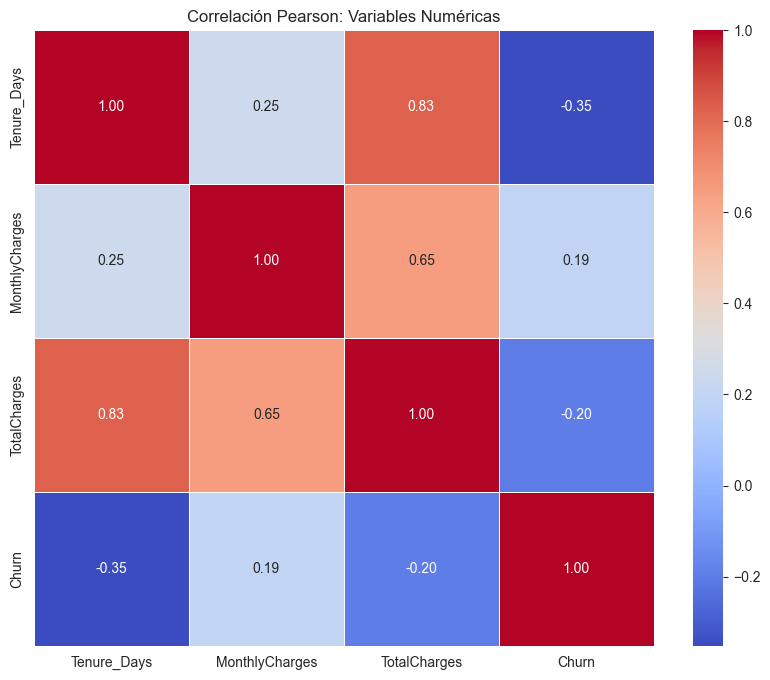

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

# 1. Distribución de la variable objetivo (Churn)
plt.figure (figsize=(6, 4))
ax = sns.countplot(data=df_merged, x='Churn', palette='coolwarm')
plt.title ('Distribución de clientes: Activos (0) vs Cancelados (1)', pad=20)
plt.xlabel ('Estados del cliente')
plt.ylabel ('Cantidad')

total = len(df_merged)
for p in ax.patches: 
    percentage =round(100*p.get_height()/total, 1)
    x = p.get_x() + p.get_width() / 2
    y = p.get_height() + 100
    ax.annotate(percentage, (x, y), ha='center', va='bottom')
plt.show()

# 2. Relación Antigüedad (Tenure) vs Churn
plt.figure (figsize=(10,6))
sns.boxplot (data = df_merged, x='Churn', y='Tenure_Days', palette='Set2')
plt.title ('Distribución de antigüedad por estado del cliente')
plt.ylabel ('Días de Antigüedad (Tenure)')
plt.show ()

# 3. Densidad de cargos Mensuales vs Churn 
plt.figure (figsize=(10,6))
sns.kdeplot (data=df_merged[df_merged['Churn']==0]['MonthlyCharges'], label='Activos (0)', fill=True, color='green', alpha=0.3)
sns.kdeplot (data=df_merged[df_merged['Churn']==1]['MonthlyCharges'], label='Cancelados (1)', fill=True, color='red', alpha=0.3)
plt.title ('Impacto de los Cargos Mensuales en la Cancelación')
plt.xlabel ('Cargos Mensuales ($)')
plt.legend ()
plt.show ()

# 4. Tasa de Cancelación por tipo de contrato 
plt.figure (figsize=(8,5))
contract_churn = df_merged.groupby('Type')['Churn'].mean().reset_index()
sns.barplot (data=contract_churn, x='Type', y='Churn', palette='viridis')
plt.title ('Probabilidad de Fuga por tipo de contrato')
plt.ylabel ('Tasa de Churn (0-1)')
plt.show ()

# 5. Mapa de Calor de correlaciones Numéricas
plt.figure (figsize=(10,8))
numeric_cols=['Tenure_Days', 'MonthlyCharges', 'TotalCharges', 'Churn']
corr_matrix = df_merged[numeric_cols].corr()
sns.heatmap (corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title ('Correlación Pearson: Variables Numéricas')
plt.show ()

### 📊 Conclusiones del Análisis Exploratorio de Datos (EDA)

A continuación, se presentan los hallazgos clave derivados de las visualizaciones, enfocados en identificar patrones de comportamiento para la estrategia de retención.

#### 1. Distribución de la Variable Objetivo (Churn)
* **Observación:** El dataset presenta un desbalance de clases moderado. Aproximadamente el **26.5%** de los clientes cancelaron su servicio (Clase 1), mientras que el **73.5%** permanecieron activos (Clase 0).
* **Insight de Negocio:** Aunque no es un evento "extremadamente raro", el desbalance es suficiente para sesgar un modelo hacia la clase mayoritaria.
* **Acción Técnica:** Se confirma la necesidad de utilizar métricas sensibles al desbalance (como **AUC-ROC** o F1-Score) y aplicar estrategias como `stratify=y` en la división de datos o `class_weight='balanced'` en los modelos.

#### 2. Antigüedad vs. Cancelación (Tenure vs Churn)
* **Observación:** Existe una clara relación inversa. La mediana de antigüedad de los clientes que se van es muy baja (alrededor de **10 meses**), mientras que los clientes leales tienen una mediana superior a los **30 meses**.
* **Insight de Negocio:** **El periodo crítico de riesgo es el primer año.** Los clientes nuevos son los más volátiles. Si Interconnect logra retener a un usuario por más de 12-18 meses, la probabilidad de fuga cae drásticamente.
* **Estrategia:** Las campañas de fidelización deben ser agresivas durante el proceso de *onboarding* (primeros 6 meses).

#### 3. Impacto de los Cargos Mensuales (KDE Plot)
* **Observación:** La curva de densidad de los usuarios que cancelan (roja) muestra un pico pronunciado en el rango de precios altos (**$70 - $100 USD**). Por el contrario, los usuarios con cargos bajos ($20-$30) tienden a quedarse.
* **Insight de Negocio:** Los clientes con facturación alta son los que más abandonan, probablemente por tener mayores expectativas de servicio o ser más sensibles a ofertas de la competencia. Perder a estos clientes es doblemente costoso por su alto valor (LTV).

#### 4. Fuga por Tipo de Contrato
* **Observación:** Esta es la variable más discriminante. Los clientes con contrato **"Month-to-month"** (mensual) tienen una tasa de cancelación masiva en comparación con los contratos de "One year" o "Two year", cuyas tasas son cercanas a cero.
* **Insight de Negocio:** La falta de compromiso contractual facilita la fuga inmediata.
* **Estrategia:** Incentivar la migración de usuarios mensuales a anuales mediante descuentos o beneficios exclusivos podría reducir el Churn significativamente.

#### 5. Mapa de Calor de Correlaciones
* **Observación:**
    * `Tenure` tiene una correlación negativa fuerte con `Churn`: A mayor tiempo, menor riesgo.
    * `MonthlyCharges` tiene una correlación positiva moderada con `Churn`: A mayor precio, mayor riesgo.
    * `TotalCharges` presenta alta colinealidad con `Tenure`, lo cual debe ser vigilado en modelos lineales.

---

#### 💡 Perfil del Cliente en Riesgo ("Churner")
Basado en el análisis, el usuario con mayor probabilidad de fuga es:
> **"Un cliente nuevo (menos de 1 año de antigüedad), con contrato mensual y que paga una factura alta (entre $70 y  $100)."**
